### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Part 1

In [2]:
def get_faces(Cube):
    faces = []
    # Face avant
    faces.append([Cube[0], Cube[1], Cube[2], Cube[3]])
    # Face arrière
    faces.append([Cube[4], Cube[5], Cube[6], Cube[7]])
    # Face gauche
    faces.append([Cube[0], Cube[1], Cube[5], Cube[4]])
    # Face droite
    faces.append([Cube[2], Cube[3], Cube[7], Cube[6]])
    # Face supérieure
    faces.append([Cube[0], Cube[3], Cube[7], Cube[4]])
    # Face inférieure
    faces.append([Cube[1], Cube[2], Cube[6], Cube[5]])
    
    return np.array(faces)

In [3]:
#Comprendre comment projeter un objet 3D sur un plan 2D et comment reconstruire ou
#approximer une forme à partir de points discrets.
#1. Définir les sommets d’un cube 3D.
#2. Implémenter la projection perspective.
#3. Visualiser le cube projeté en 2D.

Cube = np.array([[0, 0, 0],
                [1, 0, 0],
                [1, 1, 0],
                [0, 1, 0],
                [0, 0, 1],
                [1, 0, 1],
                [1, 1, 1],
                [0, 1, 1]])



In [4]:
def perspective_projection(points, d):
    projected_points = []
    for point in points:
        x, y, z = point
        if z != 0:  # Éviter la division par zéro
            x_proj = (d * x) / z
            y_proj = (d * y) / z
            projected_points.append([x_proj, y_proj])
        else:
            projected_points.append([x, y])  # Si z=0, garder les coordonnées originales
    return np.array(projected_points)
def RotateX(points, angle):
   
    rad = np.radians(angle)
    cos_a = np.cos(rad)
    sin_a = np.sin(rad)
    rotation_matrix = np.array([[1, 0, 0],
                                [0, cos_a, -sin_a],
                                [0, sin_a, cos_a]])
    return points @ rotation_matrix.T
def RotateZ(points, angle):
    
    rad = np.radians(angle)
    cos_a = np.cos(rad)
    sin_a = np.sin(rad)
    rotation_matrix = np.array([[cos_a, -sin_a, 0],
                                [sin_a, cos_a, 0],
                                [0, 0, 1]])
    return points @ rotation_matrix.T
def RotateY(points, angle):
    
    rad = np.radians(angle)
    cos_a = np.cos(rad)
    sin_a = np.sin(rad)
    rotation_matrix = np.array([[cos_a, 0, sin_a],
                                [0, 1, 0],
                                [-sin_a, 0, cos_a]])
    return points @ rotation_matrix.T

def Translate(points, translation):
    """Translation des points"""
    return points + translation

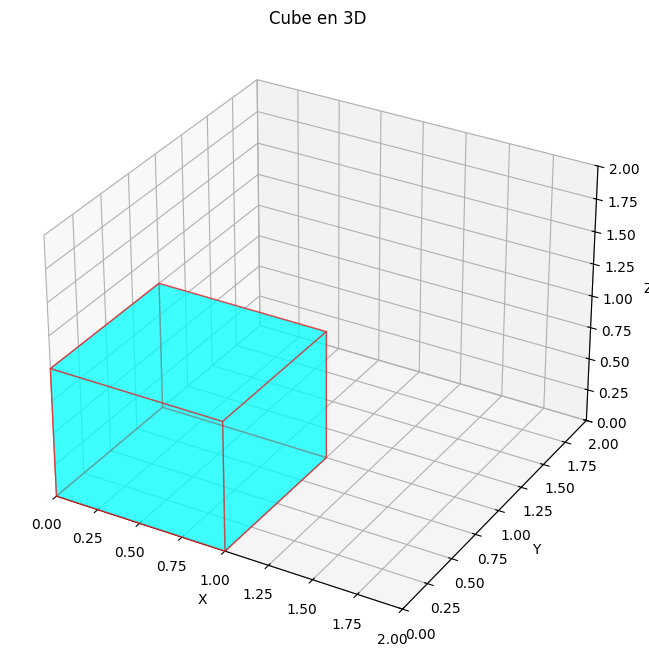

In [5]:
#draw the cube in 3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
faces = get_faces(Cube)
ax.add_collection3d(Poly3DCollection(faces, alpha=0.5, edgecolor='red', facecolor='cyan'))
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Cube en 3D')
ax.set_xlim([0, 2])
ax.set_ylim([0, 2])
ax.set_zlim([0, 2])
plt.show()


[[-0.70710678 -0.5         2.        ]
 [ 0.         -0.5         1.29289322]
 [ 0.          0.5         1.29289322]
 [-0.70710678  0.5         2.        ]
 [ 0.         -0.5         2.70710678]
 [ 0.70710678 -0.5         2.        ]
 [ 0.70710678  0.5         2.        ]
 [ 0.          0.5         2.70710678]]
[[-1.06066017 -0.75      ]
 [ 0.         -1.16018862]
 [ 0.          1.16018862]
 [-1.06066017  0.75      ]
 [ 0.         -0.55409709]
 [ 1.06066017 -0.75      ]
 [ 1.06066017  0.75      ]
 [ 0.          0.55409709]]


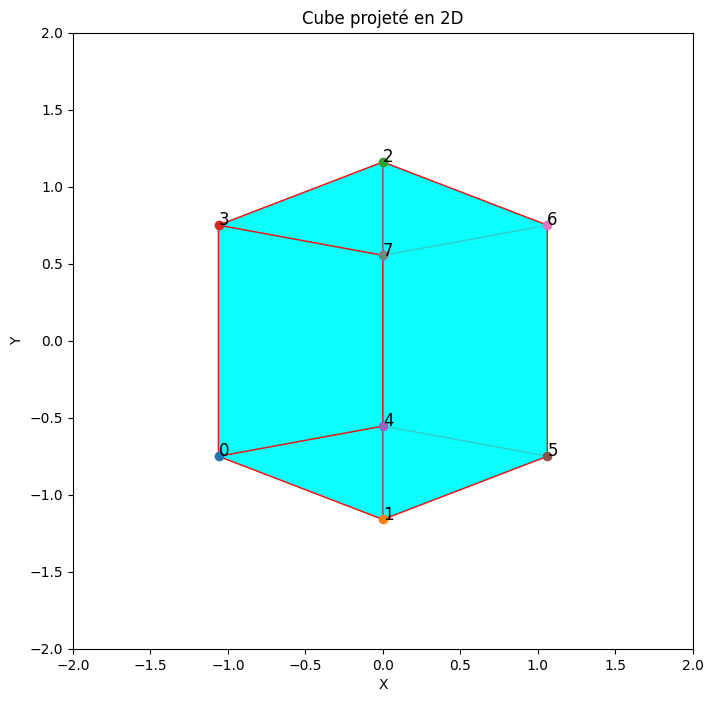

point 0:  [-0.70710678 -0.5         2.        ]
point 1:  [ 0.         -0.5         1.29289322]
point 2:  [0.         0.5        1.29289322]
point 3:  [-0.70710678  0.5         2.        ]
point 4:  [ 0.         -0.5         2.70710678]
point 5:  [ 0.70710678 -0.5         2.        ]
point 6:  [0.70710678 0.5        2.        ]
point 7:  [0.         0.5        2.70710678]


In [23]:
#plot the cube in 2D 
Translated_cube = Translate(Cube, np.array([-0.5, -0.5, -0.5]))  # Centrer le cube à l'origine
X=0
RotatedCube = RotateY(Translated_cube, 45)
RotatedCube = RotateZ(RotatedCube, 0)
RotatedCube = RotateX(RotatedCube, 0)
faces  = get_faces(RotatedCube)
Translated_cube = Translate(RotatedCube, np.array([0, 0, 2]))  # Recentrer le cube après rotation
FinalCube = Translated_cube

d=3
projected_cube = perspective_projection(FinalCube, d)
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)
projected_faces = get_faces(projected_cube)

for face in projected_faces:
    
    ax.add_patch(plt.Polygon(face, alpha=0.8, edgecolor='red', facecolor='cyan'))
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Cube projeté en 2D')
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
print(FinalCube)
print(projected_cube)

for i, point in enumerate(projected_cube):
    x, y = point
    ax.scatter(x, y)
    ax.text(x, y, str(i), fontsize=12)  
plt.show()

print("point 0: ", FinalCube[0])
print("point 1: ", FinalCube[1])
print("point 2: ", FinalCube[2])
print("point 3: ", FinalCube[3])
print("point 4: ", FinalCube[4])
print("point 5: ", FinalCube[5])
print("point 6: ", FinalCube[6])
print("point 7: ", FinalCube[7])



# ANALYZE 
the higher the z value in the point coordinates the further that point appears on the figure

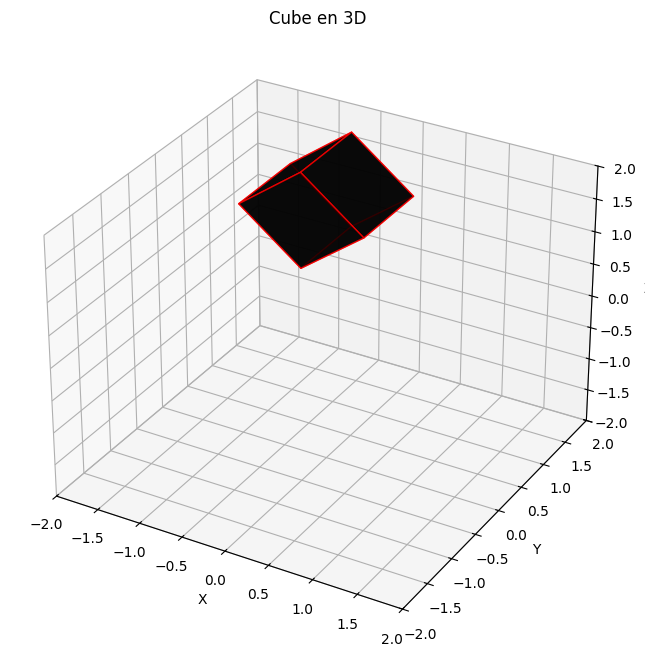

In [7]:
#draw the cube in 3D

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')
faces = get_faces(FinalCube)
ax.add_collection3d(Poly3DCollection(faces, alpha=0.8, edgecolor='red', facecolor='black'))
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Cube en 3D')
ax.set_xlim([-2, 2])
ax.set_ylim([-2, 2])
ax.set_zlim([-2, 2])
plt.show()

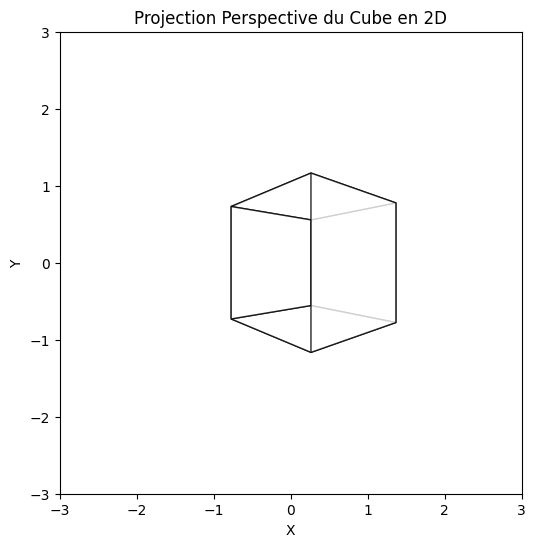

In [8]:
Rotated = RotateY(Translated_cube, 5)
projected = perspective_projection(Rotated, d)

faces  = get_faces(projected)
fig, ax = plt.subplots(figsize=(8, 6))
for face in faces:
    ax.add_patch(plt.Polygon(face, alpha=0.8, edgecolor='black', facecolor='white'))
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Projection Perspective du Cube en 2D')
ax.set_xlim([-3, 3])
ax.set_ylim([-3, 3])
ax.set_aspect('equal')

plt.show()

# trying dif values for "f"

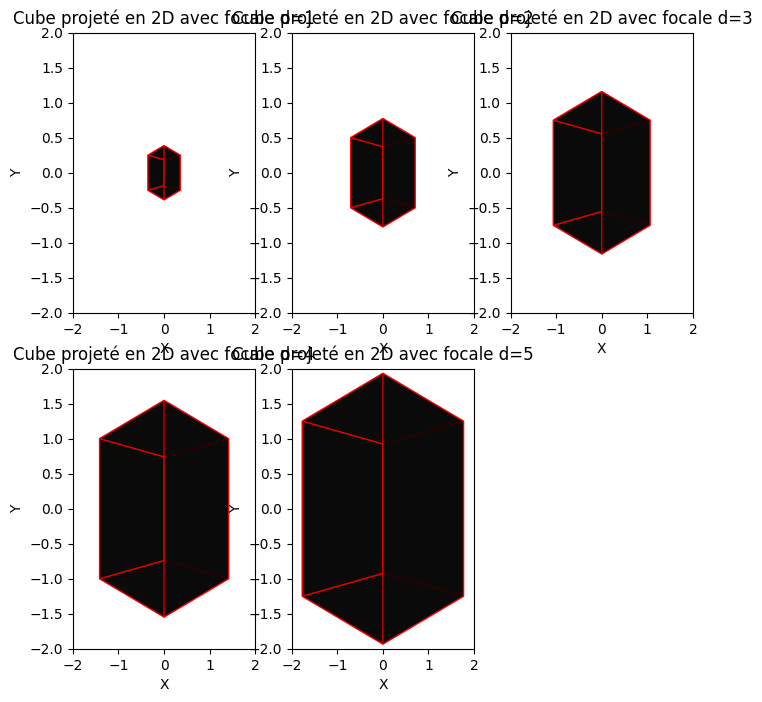

In [17]:
fig = plt.figure(figsize=(8, 8))
for d in [1, 2, 3, 4, 5]:

    projected_cube = perspective_projection(FinalCube, d)
    
    ax = fig.add_subplot(2, 3, d)
    projected_faces = get_faces(projected_cube)

    for face in projected_faces:
    
        ax.add_patch(plt.Polygon(face, alpha=0.8, edgecolor='red', facecolor='black'))
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Cube projeté en 2D avec focale d={}'.format(d))
    ax.set_xlim([-2, 2])
    ax.set_ylim([-2, 2])
    
    
plt.show()

# ANALYZE 
f simulate the human eye when you get close to an object it appears bigger

# Part 2

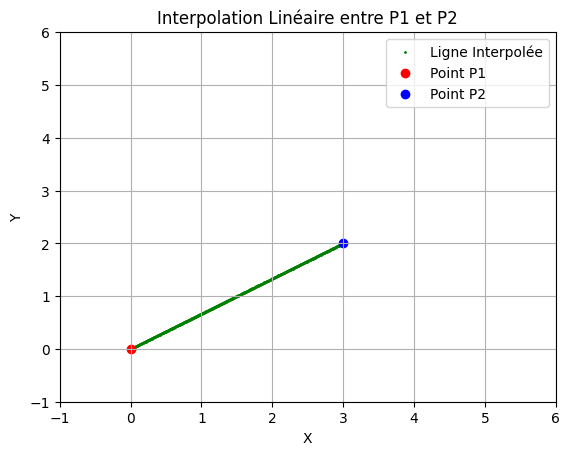

In [10]:
P1 = np.array([0, 0])
P2 = np.array([3, 2])

def interpolate(P,Q,t):
    return (1-t)*P[0] + t*Q[0], (1-t)*P[1] + t*Q[1]

def interpolation(P1, P2, values):
    t_values = np.linspace(0,1,values)
    ligne = []
    for t in t_values:
        ligne.append(interpolate(P1, P2, t))
    return np.array(ligne)

ligne = interpolation(P1, P2, 500)
plt.scatter(ligne[:,0], ligne[:,1], label='Ligne Interpolée', color='green', s=1)
plt.scatter(P1[0], P1[1], color='red', label='Point P1')
plt.scatter(P2[0], P2[1], color='blue', label='Point P2')
plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Interpolation Linéaire entre P1 et P2')
plt.legend()
plt.grid()
plt.show()






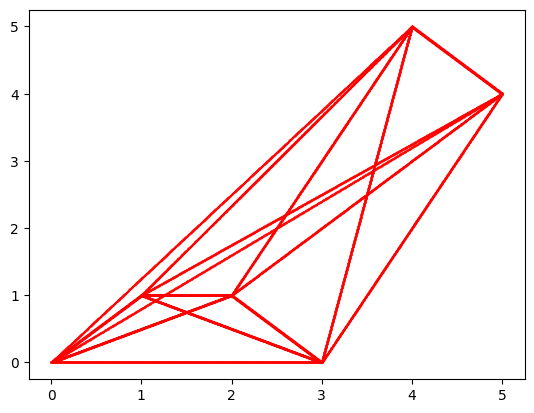

In [11]:

#Définir une série de points 2D.
#2. Implémenter l’interpolation linéaire entre chaque paire.

P1 = np.array([0, 0])
P2 = np.array([1, 1])
P3= np.array([2, 1])
P4= np.array([3, 0])
P5= np.array([4, 5])
P6= np.array([5, 4])
Points = [P1, P2, P3, P4, P5, P6]

for i in range(len(Points)):
   for j in range(i+1,len(Points)):
      ligne = interpolation(Points[i],Points[j],1000)
      plt.scatter(ligne[:,0], ligne[:,1], label='Ligne Interpolée', color='red', s=.2)
      
    

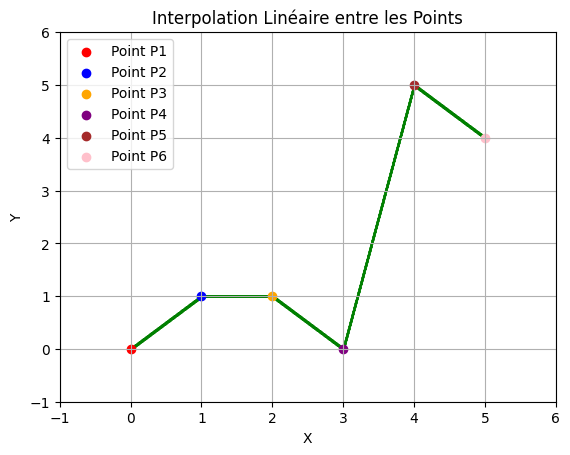

In [12]:
#Interpolation par segments successifs
Points = [P1, P2, P3, P4, P5, P6]
for i in range(len(Points)-1):
    ligne = interpolation(Points[i], Points[i+1], 1000)
    plt.scatter(ligne[:,0], ligne[:,1], color='green', s=0.2)

plt.scatter(P1[0], P1[1], color='red', label='Point P1')
plt.scatter(P2[0], P2[1], color='blue', label='Point P2')
plt.scatter(P3[0], P3[1], color='orange', label='Point P3')
plt.scatter(P4[0], P4[1], color='purple', label='Point P4')
plt.scatter(P5[0], P5[1], color='brown', label='Point P5')
plt.scatter(P6[0], P6[1], color='pink', label='Point P6')
plt.xlim(-1, 6) 
plt.ylim(-1, 6)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Interpolation Linéaire entre les Points')
plt.legend()
plt.grid()
plt.show()

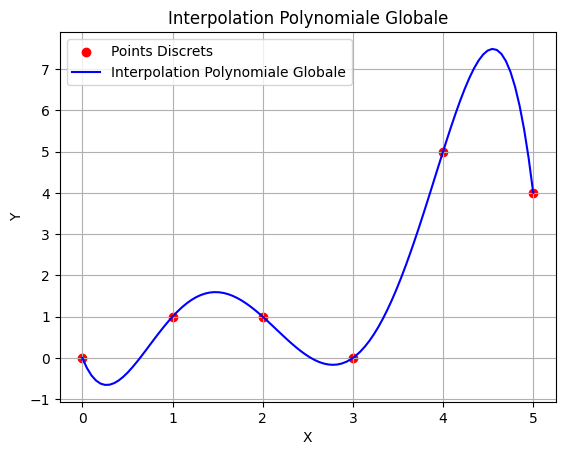

In [13]:
#interpolation polynomiale globale
P1 = np.array([0, 0])
P2 = np.array([1, 1])
P3= np.array([2, 1])
P4= np.array([3, 0])
P5= np.array([4, 5])
P6= np.array([5, 4])
Points = np.array([P1, P2, P3, P4, P5, P6])



plt.scatter(Points[:,0], Points[:,1], color='red', label='Points Discrets')
x = np.linspace(0, 5, 100)
y = np.polyval(np.polyfit(Points[:,0], Points[:,1], deg=len(Points)-1), x)
plt.plot(x, y, color='blue', label='Interpolation Polynomiale Globale')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Interpolation Polynomiale Globale')
plt.legend()
plt.grid()
plt.show()


In [14]:
#Approximation (Moindres Carrés)
# #1. Générer des points bruités autour d’une fonction connue.
#2. Ajuster un polynôme par moindres carrés.
#3. Tracer :
 #- Les points bruités,
 #- La fonction réelle,
 #- La fonction approximée.

def generate_noisy_points(func, x_range, num_points, noise_level):
    x = np.linspace(x_range[0], x_range[1], num_points)
    y = func(x) + np.random.normal(0, noise_level, size=num_points)
    return x, y
def real_function(x):
    return np.sin(x) + 0.5 * np.cos(2 * x) + 0.2 * x
x_range = (0, 30)
num_points = 100
noise_level = 0.5
x_noisy, y_noisy = generate_noisy_points(real_function, x_range, num_points, noise_level)



Text(0.5, 0, 'X')

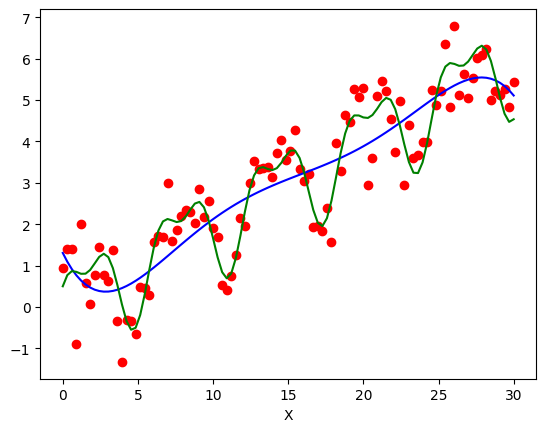

In [15]:
coefficients = np.polyfit(x_noisy, y_noisy, deg=5)
polynomial_approximation = np.poly1d(coefficients)
x_fit = np.linspace(x_range[0], x_range[1], 100)
y_fit = polynomial_approximation(x_fit)
plt.scatter(x_noisy, y_noisy, color='red', label='Points Bruités')
plt.plot(x_fit, y_fit, color='blue', label='Approximation par Moindres Carrés')
plt.plot(x_fit, real_function(x_fit), color='green', label='Fonction Réelle')
plt.xlabel('X')